## Indoor Environmental Quality (IEQ) Monitoring — Data Cleaning & Visualization

This section contains your provided code for cleaning and visualizing the sensor data from `DATA.CSV`.

In [2]:
!pip install mo


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Valid rows after cleaning: 12962
Duration: 108.2 hours (4.5 days)

T_SHT40:  min=21.07  max=28.23  mean=25.19 °C
T_SCD30:  min=24.86  max=30.79  mean=28.10 °C
RH_SHT40: min=25.93  max=66.75  mean=48.50 %
RH_SCD30: min=22.89  max=56.72  mean=40.12 %
CO2:      min=150  max=729  mean=248 ppm

SCD30-SHT40 T offset (mean):  +2.90 °C
SHT40-SCD30 RH offset (mean): +8.38 %

Figure saved to: IEQ_Monitoring_Figures.png


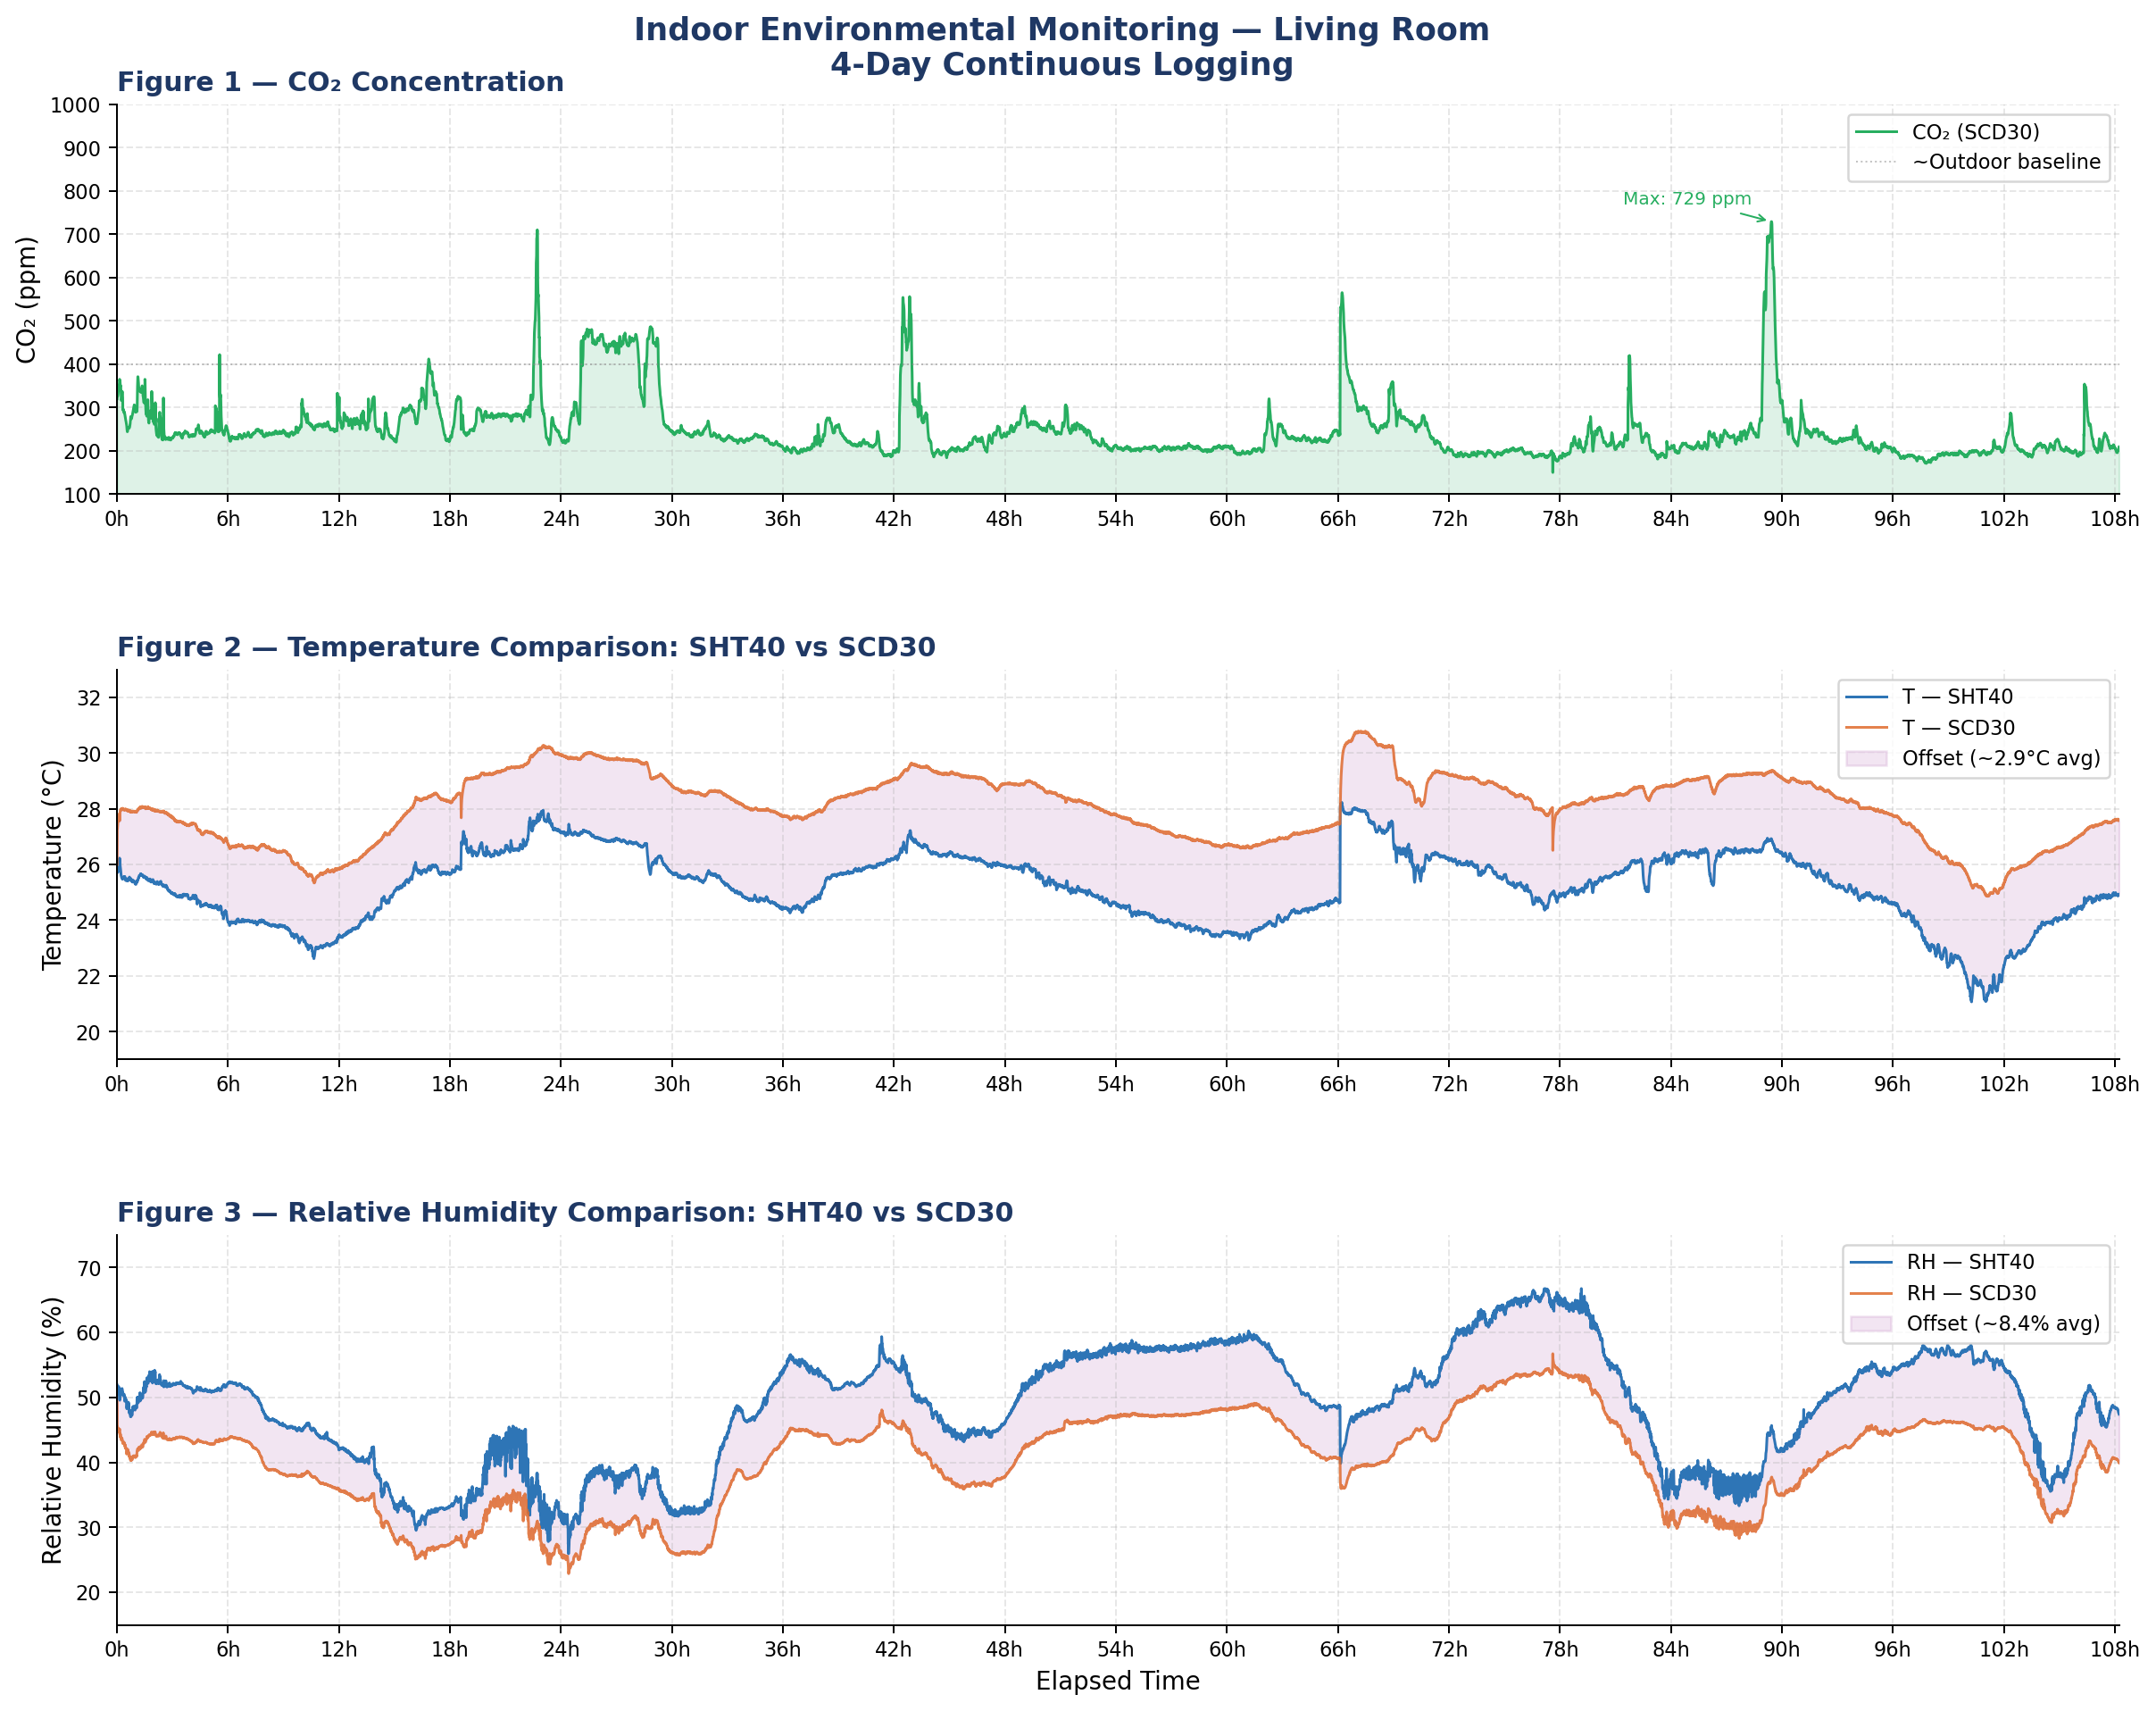

In [7]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import mo
from google.colab import drive
drive.mount('/content/drive')

# ── 1. CONFIGURATION ─────────────────────────────────────────────────────────

CSV_FILE   = "/content/drive/MyDrive/Python course/DIY/DATA (1).CSV"          # path to your CSV file
OUTPUT_PNG = "IEQ_Monitoring_Figures.png"   # output figure filename

# ── 2. DATA CLEANING & LOADING ───────────────────────────────────────────────
# The Arduino restarted several times during logging, which causes:
#   - Duplicate header lines (millis,T_SHT40,...) in the CSV
#   - millis() resetting to 0 after each restart
# Fix: detect each restart, accumulate a cumulative time offset so the
# full dataset appears as one continuous timeline.

rows = []
cumulative_offset = 0   # ms added to correct for restarts
last_ms = 0             # last valid millis value before a restart

with open(CSV_FILE) as f:
    for line in f:
        line = line.strip()

        # Skip empty lines
        if not line:
            continue

        # Header line = restart detected → update cumulative offset
        if line.startswith('millis'):
            if last_ms > 0:
                # Add last known millis + one 30s interval as the gap
                cumulative_offset += last_ms + 30000
            continue

        parts = line.split(',')
        if len(parts) != 6:
            continue

        try:
            r = [float(x) for x in parts]
        except ValueError:
            continue

        # Exclude SCD30 startup rows where sensor outputs 0
        if r[3] <= 0 or r[4] <= 0:
            continue

        # Build corrected timeline
        corrected_ms = r[0] + cumulative_offset
        last_ms = r[0]

        rows.append([corrected_ms] + r[1:])

print(f"Valid rows after cleaning: {len(rows)}")

# Convert to numpy arrays
hours  = np.array([r[0] / 3_600_000 for r in rows])   # ms → hours
t_sht  = np.array([r[1] for r in rows])                # °C  SHT40
rh_sht = np.array([r[2] for r in rows])                # %   SHT40
co2    = np.array([r[3] for r in rows])                 # ppm SCD30
t_scd  = np.array([r[4] for r in rows])                # °C  SCD30
rh_scd = np.array([r[5] for r in rows])                # %   SCD30

print(f"Duration: {hours[-1]:.1f} hours ({hours[-1]/24:.1f} days)")
print(f"\nT_SHT40:  min={t_sht.min():.2f}  max={t_sht.max():.2f}  mean={t_sht.mean():.2f} °C")
print(f"T_SCD30:  min={t_scd.min():.2f}  max={t_scd.max():.2f}  mean={t_scd.mean():.2f} °C")
print(f"RH_SHT40: min={rh_sht.min():.2f}  max={rh_sht.max():.2f}  mean={rh_sht.mean():.2f} %")
print(f"RH_SCD30: min={rh_scd.min():.2f}  max={rh_scd.max():.2f}  mean={rh_scd.mean():.2f} %")
print(f"CO2:      min={co2.min():.0f}  max={co2.max():.0f}  mean={co2.mean():.0f} ppm")
print(f"\nSCD30-SHT40 T offset (mean):  +{(t_scd - t_sht).mean():.2f} °C")
print(f"SHT40-SCD30 RH offset (mean): +{(rh_sht - rh_scd).mean():.2f} %")

# ── 3. PLOT SETTINGS ─────────────────────────────────────────────────────────

C_SHT = '#2E75B6'    # blue  — SHT40
C_SCD = '#E06C2E'    # orange — SCD30
C_CO2 = '#27AE60'    # green  — CO2
GRAY  = '#888888'

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 12,
    'legend.fontsize'   : 9,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
})

# X-axis ticks every 6 hours
x_ticks  = np.arange(0, hours[-1] + 1, 6)
x_labels = [f"{int(h)}h" for h in x_ticks]

# ── 4. FIGURE ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 11))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(3, 1, hspace=0.45, top=0.93, bottom=0.07,
                        left=0.08, right=0.97)

fig.suptitle(
    'Indoor Environmental Monitoring — Living Room\n4-Day Continuous Logging',
    fontsize=14, fontweight='bold', color='#1F3864', y=0.98
)

# ── Panel 1: CO2 ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(hours, co2, alpha=0.15, color=C_CO2)
ax1.plot(hours, co2, color=C_CO2, lw=1.2, label='CO₂ (SCD30)')
ax1.axhline(400,  color=GRAY,   lw=0.8, ls=':', alpha=0.5, label='~Outdoor baseline')
ax1.set_ylabel('CO₂ (ppm)')
ax1.set_title('Figure 1 — CO₂ Concentration',
              fontweight='bold', loc='left', color='#1F3864')
ax1.set_xlim(0, hours[-1])
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_labels)
ax1.set_ylim(100, 1000) # Adjusted ylim to accommodate potential dummy CO2 values
ax1.legend(loc='upper right', framealpha=0.8)
# Annotate peak
peak_idx = co2.argmax()
ax1.annotate(
    f'Max: {co2.max():.0f} ppm',
    xy=(hours[peak_idx], co2.max()),
    xytext=(hours[peak_idx] - 8, co2.max() + 40),
    fontsize=8, color=C_CO2,
    arrowprops=dict(arrowstyle='->', color=C_CO2, lw=0.8)
)

# ── Panel 2: Temperature ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(hours, t_sht, color=C_SHT, lw=1.2, label='T — SHT40')
ax2.plot(hours, t_scd, color=C_SCD, lw=1.2, label='T — SCD30', alpha=0.85)
ax2.fill_between(hours, t_sht, t_scd, alpha=0.1, color='purple',
                 label=f'Offset (~{(t_scd-t_sht).mean():.1f}°C avg)')
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Figure 2 — Temperature Comparison: SHT40 vs SCD30',
              fontweight='bold', loc='left', color='#1F3864')
ax2.set_xlim(0, hours[-1])
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(x_labels)
ax2.set_ylim(19, 33)
ax2.legend(loc='upper right', framealpha=0.8)

# ── Panel 3: Relative Humidity ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(hours, rh_sht, color=C_SHT, lw=1.2, label='RH — SHT40')
ax3.plot(hours, rh_scd, color=C_SCD, lw=1.2, label='RH — SCD30', alpha=0.85)
ax3.fill_between(hours, rh_sht, rh_scd, alpha=0.1, color='purple',
                 label=f'Offset (~{(rh_sht-rh_scd).mean():.1f}% avg)')
ax3.set_ylabel('Relative Humidity (%)')
ax3.set_xlabel('Elapsed Time')
ax3.set_title('Figure 3 — Relative Humidity Comparison: SHT40 vs SCD30',
              fontweight='bold', loc='left', color='#1F3864')
ax3.set_xlim(0, hours[-1])
ax3.set_xticks(x_ticks)
ax3.set_xticklabels(x_labels)
ax3.set_ylim(15, 75)
ax3.legend(loc='upper right', framealpha=0.8)

# ── 5. SAVE ───────────────────────────────────────────────────────────────────
plt.savefig(OUTPUT_PNG, dpi=180, bbox_inches='tight', facecolor='white')
print(f"\nFigure saved to: {OUTPUT_PNG}")

# Display the plot in Colab
from IPython.display import Image
Image(filename=OUTPUT_PNG)
